# 📝 EDA Worksheet — Auto-MPG Dataset
**Student Name:** ___________________________  |  **Date:** _______________

Complete every `# TODO` cell. Run the cells in order.  
Answer the written questions in the Markdown cells provided.

---
**Dataset:** Auto-MPG (UCI) | 398 rows × 9 columns


## Task 1 — Import Libraries

In [1]:
# TODO: Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# Also set sns theme to 'whitegrid' and default figure size to (10,5)
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)



## Task 2 — Load & Inspect Data

In [2]:
# TODO: Load the Auto-MPG dataset from the UCI repository URL below.
# Column names: ['mpg','cylinders','displacement','horsepower','weight',
#                'acceleration','model_year','origin','car_name']
# Missing values are marked with '?'
# URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']

df = pd.read_csv(url, delim_whitespace=True, names=col_names, na_values='?')

print("Shape:", df.shape)
df.head()


C:\Users\Mani\AppData\Local\Temp\ipykernel_19512\498082950.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, names=col_names, na_values='?')


Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
# TODO: Print df.info() to inspect dtypes and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [5]:
# TODO: Print df.describe() to view summary statistics
df.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


**Q1.** How many rows and columns does the dataset have?  
**Answer:** 398,9

**Q2.** Which column contains missing values and how many?  
**Answer:** mpg_level and 1


In [4]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

## Task 3 — Pre-Processing

In [5]:
# TODO: Check and print missing values per column
# Then drop all rows that contain NaN values (they are < 2% of data)
print("Missing values per column:\n", df.isna().sum())
df.dropna(inplace=True)
print("\nAfter dropping NaNs, new shape:", df.shape)


Missing values per column:
 mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

After dropping NaNs, new shape: (392, 9)


In [6]:
# TODO: Check for and remove duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
df.drop_duplicates(inplace=True)
print("After removing duplicates, new shape:", df.shape)    


Number of duplicate rows: 0
After removing duplicates, new shape: (392, 9)


In [7]:
# TODO:
# 1. Convert 'cylinders' and 'model_year' to category dtype
df['cylinders'] = df['cylinders'].astype('category')
df['model_year'] = df['model_year'].astype('category')
# 2. Map 'origin' from {1,2,3} to {'usa','europe','japan'}
origin_mapping = {1: 'usa', 2: 'europe', 3: 'japan'}
df['origin'] = df['origin'].map(origin_mapping) 
# 3. Strip & lowercase 'car_name'
df['car_name'] = df['car_name'].str.strip().str.lower()




In [8]:
# TODO: Create two lists:
# cat_cols — categorical column names (cylinders, origin, model_year)

# num_cols — numerical column names (mpg, displacement, horsepower, weight, acceleration)

cat_cols = ['cylinders', 'origin', 'model_year']   # fill in
num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']   # fill in


## Task 4 — Feature Engineering

In [9]:
# TODO: Create 'mpg_level' column using pd.cut()

# Bins: [0,17) → 'low', [17,29) → 'medium', [29, max] → 'high'
bins = [0, 17, 29, df['mpg'].max()]
labels = ['low', 'medium', 'high']
df['mpg_level'] = pd.cut(df['mpg'], bins=bins, labels=labels, right=False)  
print(df[['mpg', 'mpg_level']].head()) 

    mpg mpg_level
0  18.0    medium
1  15.0       low
2  18.0    medium
3  16.0       low
4  17.0    medium


In [10]:
# TODO: Create 'car_company' by extracting the first word from 'car_name'
df['car_company'] = df['car_name'].str.split().str[0]
print(df[['car_name', 'car_company']].head())   


                    car_name car_company
0  chevrolet chevelle malibu   chevrolet
1          buick skylark 320       buick
2         plymouth satellite    plymouth
3              amc rebel sst         amc
4                ford torino        ford


## Task 5 — Categorical EDA

<Axes: xlabel='cylinders', ylabel='count'>

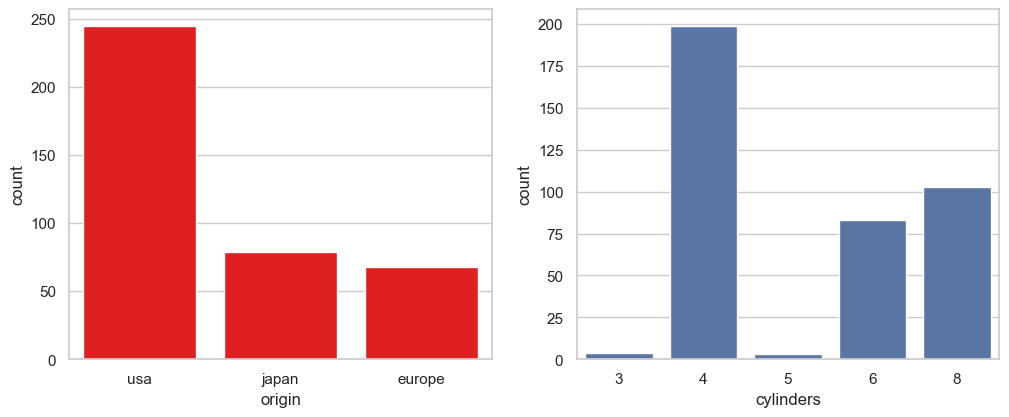

In [11]:
# TODO: Plot a countplot for each of: origin, cylinders, mpg_level, model_year

# Arrange them in a 2×2 grid of subplots
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='origin', color='red')
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='cylinders')   



In [12]:
# TODO: Print the proportion (%) of the dominant class for
# origin, cylinders, and mpg_level
print("Proportion of dominant class for 'origin':")
print(df['origin'].value_counts(normalize=True) * 100)




Proportion of dominant class for 'origin':
origin
usa       62.500000
japan     20.153061
europe    17.346939
Name: proportion, dtype: float64


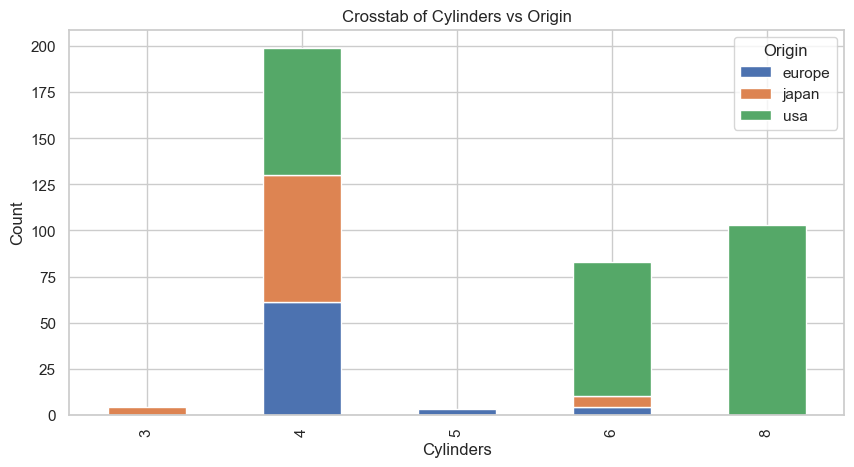

In [13]:
# TODO: Create a crosstab of cylinders vs origin and visualise as a bar chart
crosstab = pd.crosstab(df['cylinders'], df['origin'])
crosstab.plot(kind='bar', stacked=True)
plt.title('Crosstab of Cylinders vs Origin')
plt.xlabel('Cylinders')
plt.ylabel('Count')
plt.legend(title='Origin')
plt.show()


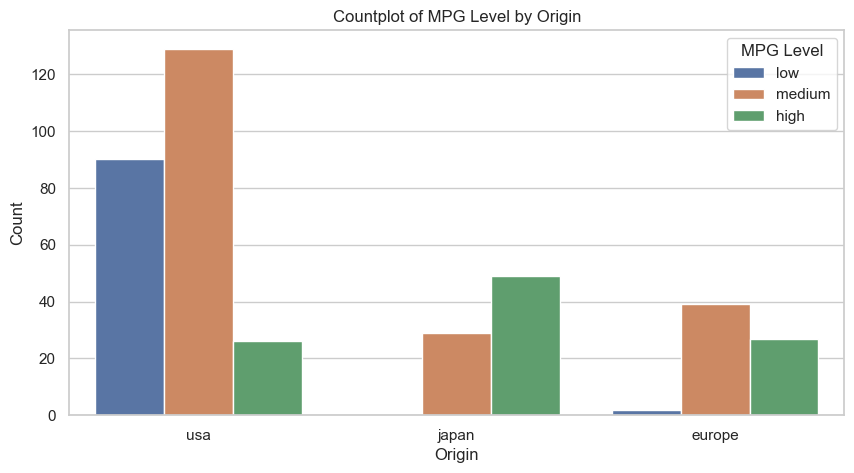

In [16]:
# TODO: Plot a countplot of mpg_level grouped by origin (use hue='mpg_level')
sns.countplot(data=df, x='origin', hue='mpg_level')
plt.title('Countplot of MPG Level by Origin')
plt.xlabel('Origin')
plt.ylabel('Count')
plt.legend(title='MPG Level')
plt.show()


**Q3.** Which origin has **no** vehicles with low mpg_level?  
**Answer:** _______________

**Q4.** Which cylinder count is most common, and what percentage does it represent?  
**Answer:** _______________


## Task 6 — Numerical EDA

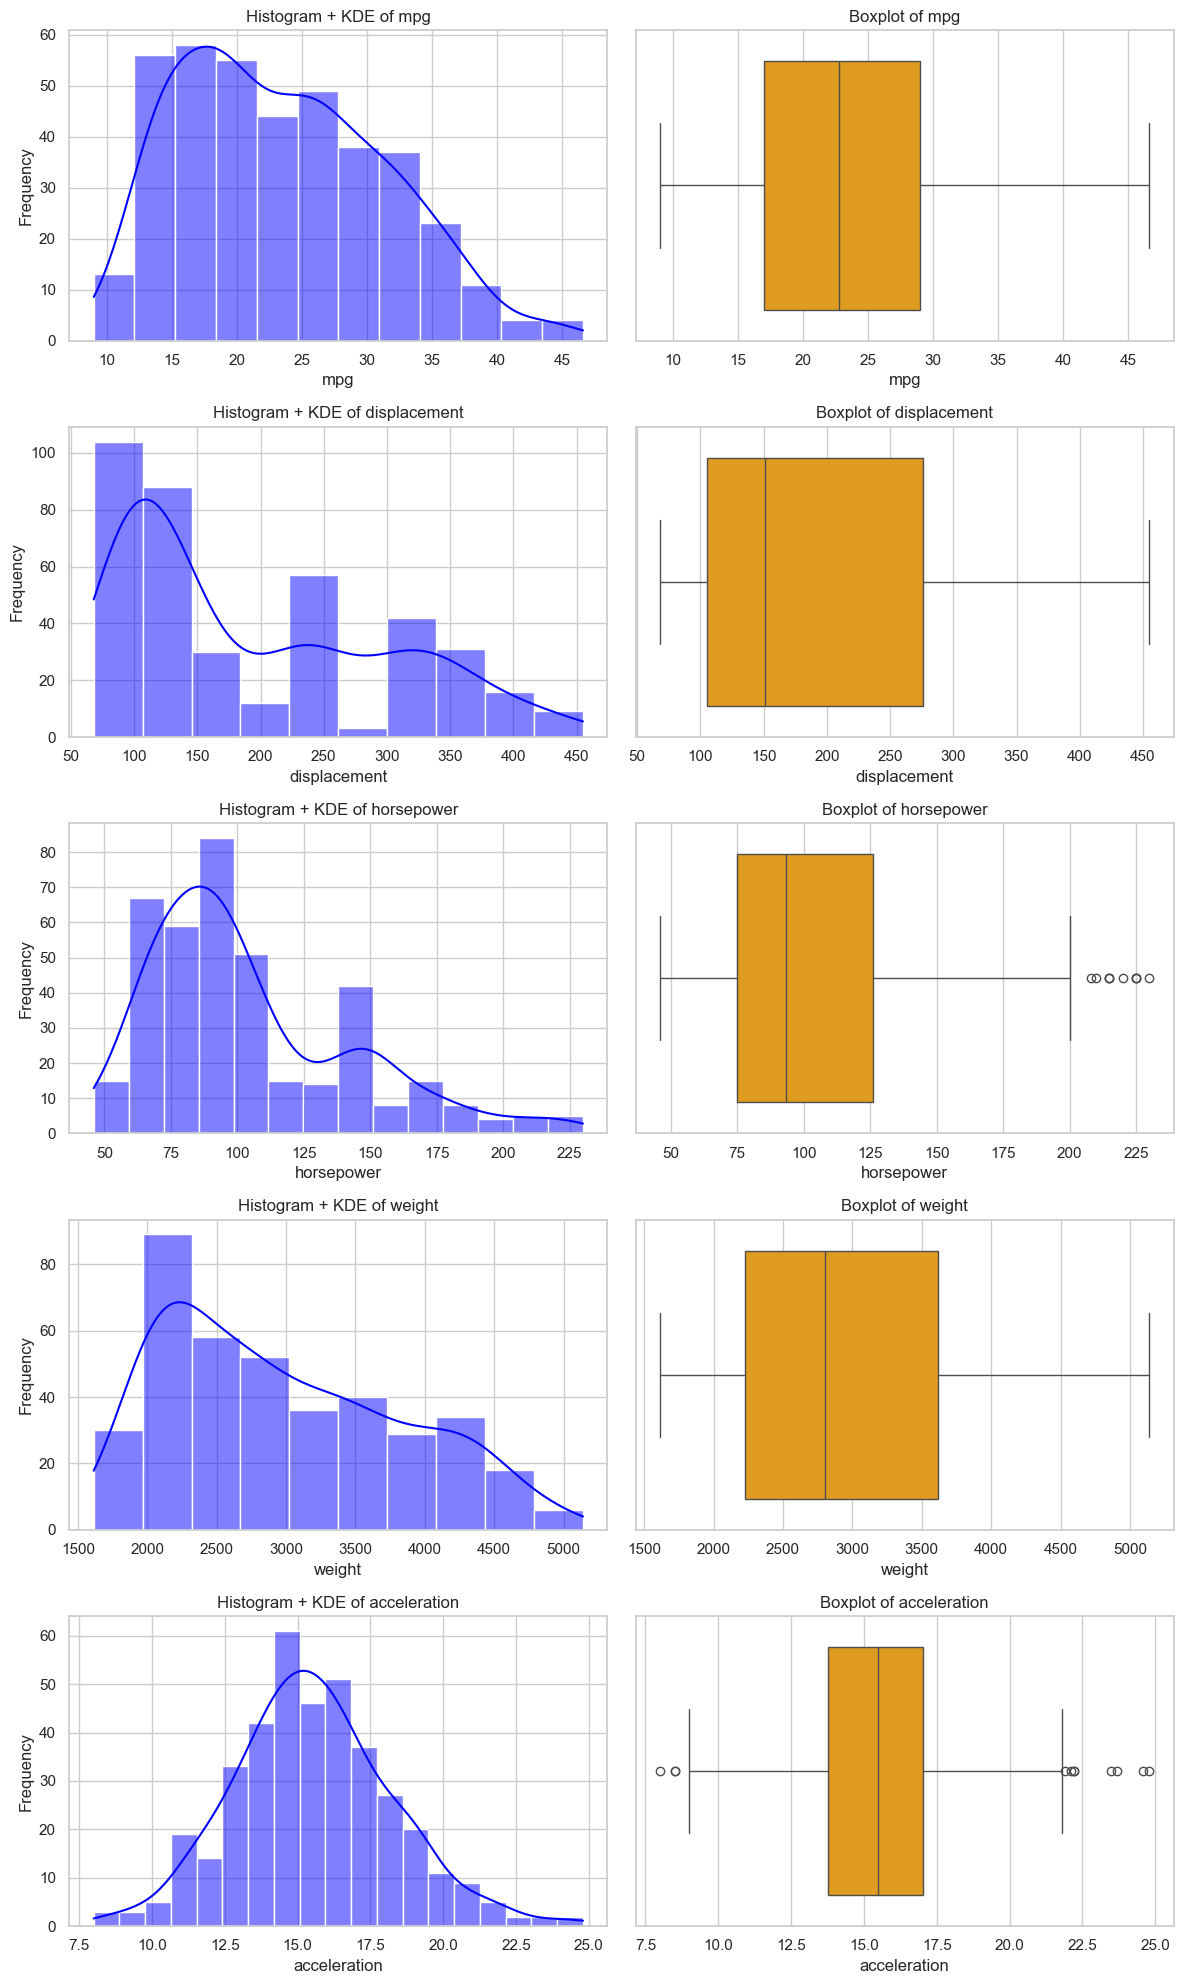

In [17]:
# TODO: For each numerical column plot:
#   (a) Histogram + KDE  (b) Boxplot
# Arrange in a grid (n_cols rows × 2 columns)
num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
n_cols = len(num_cols)
plt.figure(figsize=(12, n_cols * 4))
for i, col in enumerate(num_cols):
    plt.subplot(n_cols, 2, 2*i + 1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Histogram + KDE of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    plt.subplot(n_cols, 2, 2*i + 2)
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.ylabel('')
plt.tight_layout()
plt.show()



In [18]:
# TODO: Write a function tukey_outliers(series) that returns the outlier values
# using the IQR (Tukey) rule: Q1 - 1.5*IQR  and  Q3 + 1.5*IQR
# Then print the outlier count for each numerical column

def tukey_outliers(series):
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = series[(series < lower_bound) | (series > upper_bound)]
        return outliers
for col in num_cols:
    outliers = tukey_outliers(df[col])
    print(f"Number of outliers in '{col}': {len(outliers)}")




Number of outliers in 'mpg': 0
Number of outliers in 'displacement': 0
Number of outliers in 'horsepower': 10
Number of outliers in 'weight': 0
Number of outliers in 'acceleration': 11


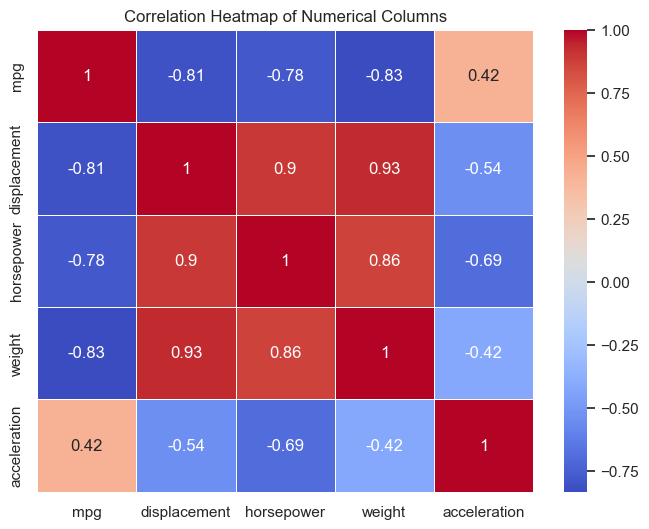

In [19]:
# TODO: Plot a correlation heatmap for all numerical columns (use annot=True)
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()  



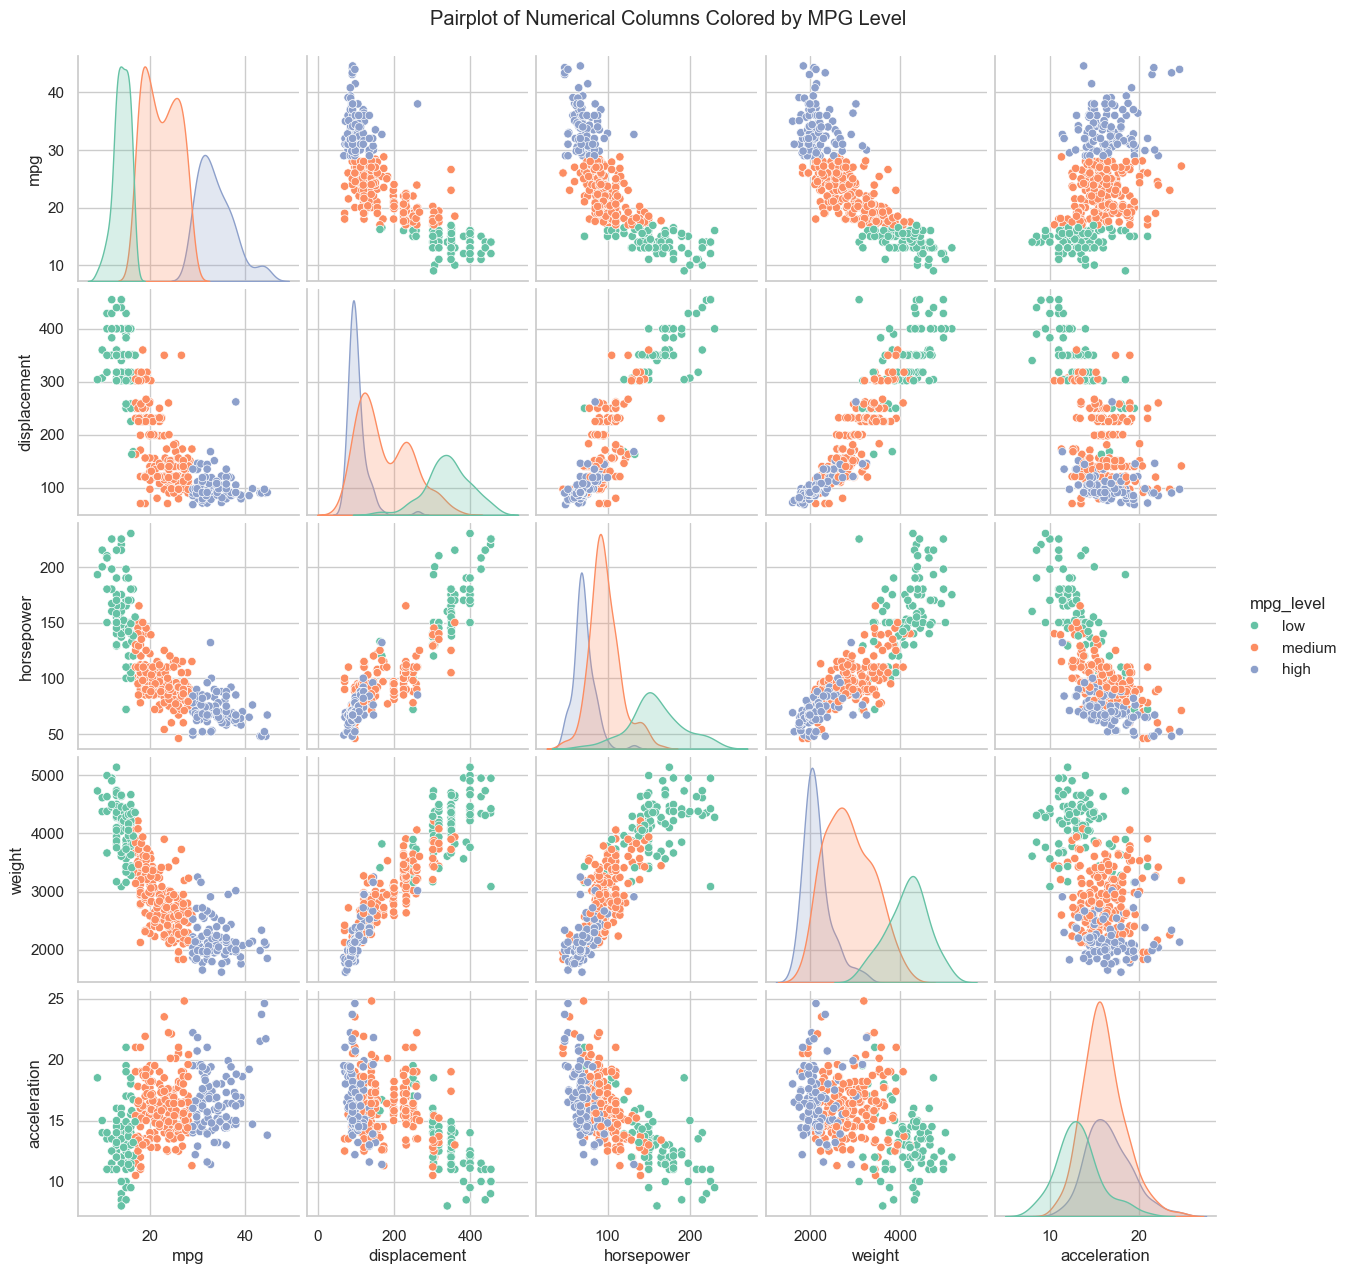

In [20]:
# TODO: Create a pairplot of numerical columns, coloured by mpg_level
sns.pairplot(df[num_cols + ['mpg_level']], hue='mpg_level', palette='Set2')
plt.suptitle('Pairplot of Numerical Columns Colored by MPG Level', y=1.02)
plt.show()  



**Q5.** Which two numerical features have the strongest negative correlation with mpg?  
**Answer:** _______________

**Q6.** Is the `acceleration` distribution approximately Gaussian? Justify briefly.  
**Answer:** _______________


## Task 7 — Numerical vs Categorical

In [ ]:
# TODO: Plot boxenplots of all numerical features grouped by 'origin'
# (1 row × 5 column subplot grid)



In [ ]:
# TODO: Plot violinplots of all numerical features grouped by 'mpg_level'



In [ ]:
# TODO: Plot a line chart showing mean mpg per model_year



**Q7.** On average, which origin produces cars with the lowest mpg?  
**Answer:** _______________

**Q8.** Describe in one sentence how mpg changes as model_year increases.  
**Answer:** _______________


## Task 8 — Summary Table
Fill in the table below based on your analysis.

| Feature | Relationship with MPG | Strength |
|---|---|---|
| displacement | | |
| horsepower | | |
| weight | | |
| acceleration | | |
| cylinders | | |
| origin | | |
| model_year | | |
